In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('data (2).csv', encoding='utf-8')
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [5]:
print(df.dtypes)

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [6]:
df['Дата'] = pd.to_datetime(df['Дата'])
print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сгруппируйте данные по дате, посчитайте количество продаж

In [8]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Вывести несколько первых строк сгруппированных данных

In [9]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

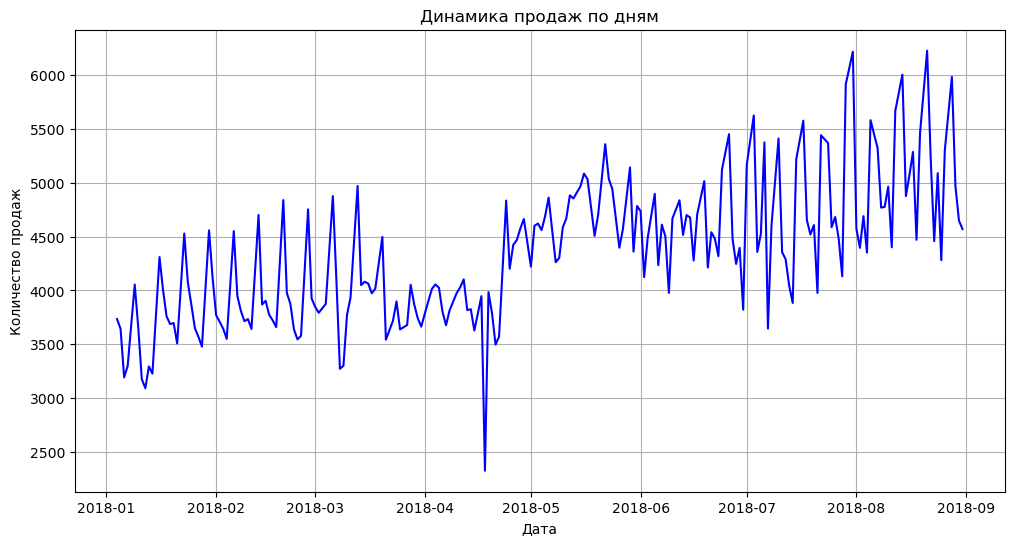

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(grouped_df['Дата'], grouped_df['Количество'], color='blue')
plt.title('Динамика продаж по дням')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
Бизнес развивается успешно, деманстрируя рост продаж. Однако необходимо обратить внемание на резкое подение в конце 
апреля для выяснения причин, а также учитовать высокую волятильность при планирований товарных запасов.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [13]:
max_index = df['Количество'].idxmax()
max_row = df.loc[max_index]
print("Строка с максимальным количеством продаж:")
print(max_row)

Строка с максимальным количеством продаж:
Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [14]:
df['Дата'] = pd.to_datetime(df['Дата'])
summer_wednesdays = df[(df['Дата'].dt.month.isin([6, 7, 8])) & (df['Дата'].dt.dayofweek == 2)]
top_product = summer_wednesdays.groupby('Номенклатура')['Количество'].sum().idxmax()
print(f"Топовый товар по средамлетом: {top_product}")

Топовый товар по средамлетом: product_1


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [16]:
import pandas as pd
file_name = '35188.01.01.2018.31.08.2018.1.0.0.ru.utf8.00000000.csv.gz'
weather_df = pd.read_csv(file_name, sep=';', skiprows=6, compression='gzip', encoding='utf-8')
print(weather_df.head())

                  Местное время в Астане      T     Po    P    Pa  \
31.08.2018 23:00                     8.2  736.6  768.3  0.2  78.0   
31.08.2018 20:00                     9.6  736.4  767.9  1.2  88.0   
31.08.2018 17:00                    11.3  735.2  766.4  0.4  83.0   
31.08.2018 14:00                    12.3  734.8  765.9  0.9  80.0   
31.08.2018 11:00                    13.2  733.9  764.8  1.0  83.0   

                                                       U  DD  Ff  ff10  \
31.08.2018 23:00          Ветер, дующий с северо-востока   4 NaN   NaN   
31.08.2018 20:00    Ветер, дующий с западо-северо-запада   3 NaN   NaN   
31.08.2018 17:00  Ветер, дующий с востоко-северо-востока   4 NaN   NaN   
31.08.2018 14:00          Ветер, дующий с северо-востока   4 NaN   NaN   
31.08.2018 11:00   Ветер, дующий с северо-северо-востока   4 NaN   NaN   

                                        ff3  ...  \
31.08.2018 23:00                  70 – 80%.  ...   
31.08.2018 20:00  90  или более, но 

In [22]:
print("Колонки в grouped_df:", grouped_df.columns.tolist())
print("Колонки в daily_weather:", daily_weather.columns.tolist())

Колонки в grouped_df: ['Дата', 'Количество']
Колонки в daily_weather: ['Дата', 'Температура']


In [18]:
weather_df = weather_df.rename(columns={'Местное время в Астане': 'Дата', 'T': 'Температура'})
weather_df['Дата'] = pd.to_datetime(weather_df['Дата'], dayfirst=True).dt.normalize()
daily_weather = weather_df.groupby('Дата')['Температура'].mean().reset_index()
print(daily_weather.head())

        Дата  Температура
0 1969-12-31   739.516216
1 1970-01-01   727.900161


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
grouped_df.columns = ['Дата', 'Количество']
daily_weather.columns = ['Дата', 'Температура']
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.normalize()
daily_weather['Дата'] = pd.to_datetime(daily_weather['Дата']).dt.normalize()
merged_df =pd.merge(grouped_df, daily_weather, on='Дата', how='left')
print("Первые 5 строк объединенной таблицы:")
print(merged_df.head())

Первые 5 строк объединенной таблицы:
        Дата  Количество  Температура
0 2018-01-04        3734          NaN
1 2018-01-05        3643          NaN
2 2018-01-06        3193          NaN
3 2018-01-07        3298          NaN
4 2018-01-09        4055          NaN


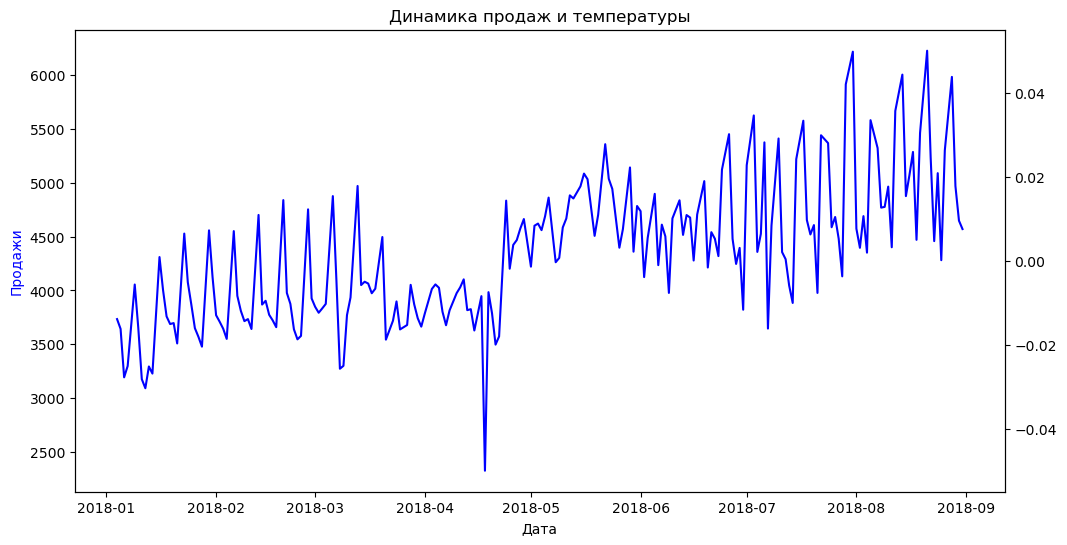

In [27]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(merged_df['Дата'], merged_df['Количество'], color='blue', label='Продажи')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Продажи', color='blue')
ax2 = ax1.twinx()
ax2.plot(merged_df['Дата'], merged_df['Температура'], color='red', linestyle='--', label='Температура')
plt.title('Динамика продаж и температуры')
plt.show()